<a href="https://colab.research.google.com/github/Mageed-Ghaleb/OptimizationSystems-Course/blob/main/LP_Concrete_01.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
!pip -q install pyomo ortools cvxpy highspy

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 29.8/29.8 MB 48.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 135.8/135.8 kB 10.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 323.3/323.3 kB 26.9 MB/s eta 0:00:00
ERROR: pip's dependency resolver does not currently take into account all the packages that are installed. This behaviour is the source of the following dependency conflicts.
grpcio-status 1.71.2 requires protobuf<6.0dev,>=5.26.1, but you have protobuf 6.33.4 which is incompatible.
tensorflow 2.19.0 requires protobuf!=4.21.0,!=4.21.1,!=4.21.2,!=4.21.3,!=4.21.4,!=4.21.5,<6.0.0dev,>=3.20.3, but you have protobuf 6.33.4 which is incompatible.
google-ai-generativelanguage 0.6.15 requires protobuf!=4.21.0,!=4.21.1,!=4.21.2,!=4.21.3,!=4.21.4,!=4.21.5,<6.0.0dev,>=3.20.2, but you have protobuf 6.33.4 which is incompatible.


In [5]:
from pyomo.environ import SolverFactory
import ortools
import cvxpy as cp
import highspy

print("HiGHS (highspy) version:", highspy.Highs().version())
print("Pyomo HiGHS available:", bool(SolverFactory("highs").available()))
print("CVXPY has HIGHS symbol:", hasattr(cp, "HIGHS"))

HiGHS (highspy) version: 1.12.0
Pyomo HiGHS available: True
CVXPY has HIGHS symbol: True


*   Maximize 3x1 + 2x2
*   2x1 + x2 <= 100
*   x1 + x2 <= 80
*   x1 <= 40
*   x1, x2 >= 0














In [33]:
from pyomo.environ import (
    ConcreteModel, AbstractModel, Var, Objective, Constraint, NonNegativeReals, NonNegativeIntegers, Binary, minimize, maximize, Set, value, Param
)
from pyomo.environ import SolverFactory

In [9]:
model = ConcreteModel()

model.x1 = Var(domain=NonNegativeReals)
model.x2 = Var(domain=NonNegativeReals)

model.obj = Objective(expr=3*model.x1 + 2*model.x2, sense=maximize)

model.c1 = Constraint(expr=2*model.x1 + model.x2 <= 100)
model.c2 = Constraint(expr=model.x1 + model.x2 <= 80)
model.c3 = Constraint(expr=model.x1 <= 40)

solver = SolverFactory("highs")

results = solver.solve(model, tee=True)

Running HiGHS 1.12.0 (git hash: 755a8e0): Copyright (c) 2025 HiGHS under MIT licence terms
LP has 3 rows; 2 cols; 5 nonzeros
Coefficient ranges:
  Matrix  [1e+00, 2e+00]
  Cost    [2e+00, 3e+00]
  Bound   [0e+00, 0e+00]
  RHS     [4e+01, 1e+02]
Presolving model
2 rows, 2 cols, 4 nonzeros  0s
2 rows, 2 cols, 4 nonzeros  0s
Presolve reductions: rows 2(-1); columns 2(-0); nonzeros 4(-1) 
Solving the presolved LP
Using EKK dual simplex solver - serial
  Iteration        Objective     Infeasibilities num(sum)
          0    -1.9999937513e+00 Ph1: 2(2); Du: 1(1.99999) 0s
          2    -1.8000000000e+02 Pr: 0(0) 0s

Performed postsolve
Solving the original LP from the solution after postsolve

Model status        : Optimal
Simplex   iterations: 2
Objective value     :  1.8000000000e+02
P-D objective error :  0.0000000000e+00
HiGHS run time      :          0.00


In [14]:
print("Status:", results.solver.status)
print("Solution Optimiality:", results.solver.termination_condition)
print("Objective Value:", value(model.obj))
print("Dec var 1:", value(model.x1), "Dec var 2:", value(model.x2))

Status: ok
Solution Optimiality: optimal
Objective Value: 180.0
Dec var 1: 20.0 Dec var 2: 60.0


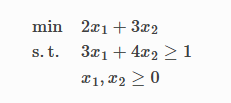

In [29]:
model_2 = ConcreteModel()

model_2.x1 = Var(domain=NonNegativeReals)
model_2.x2 = Var(domain=NonNegativeReals)

model_2.obj = Objective(expr=2*model_2.x1 + 3*model_2.x2, sense=minimize)

model_2.c1 = Constraint(expr=3*model_2.x1 + 4*model_2.x2 >= 1)

solver_2 = SolverFactory("highs")

results_2 = solver_2.solve(model_2, tee=True)

Running HiGHS 1.12.0 (git hash: 755a8e0): Copyright (c) 2025 HiGHS under MIT licence terms
LP has 1 row; 2 cols; 2 nonzeros
Coefficient ranges:
  Matrix  [3e+00, 4e+00]
  Cost    [2e+00, 3e+00]
  Bound   [0e+00, 0e+00]
  RHS     [1e+00, 1e+00]
Presolving model
1 rows, 1 cols, 1 nonzeros  0s
0 rows, 0 cols, 0 nonzeros  0s
Presolve reductions: rows 0(-1); columns 0(-2); nonzeros 0(-2) - Reduced to empty
Performed postsolve
Solving the original LP from the solution after postsolve

Model status        : Optimal
Objective value     :  6.6666666667e-01
P-D objective error :  0.0000000000e+00
HiGHS run time      :          0.00


In [30]:
print("Status:", results_2.solver.status)
print("Termination:", results_2.solver.termination_condition)
print("Objective Value:", value(model_2.obj))
print("Dec var 1:", value(model_2.x1), "Dec var 2:", value(model_2.x2))

Status: ok
Termination: optimal
Objective Value: 0.6666666666666666
Dec var 1: 0.3333333333333333 Dec var 2: 0.0


In [31]:
model = ConcreteModel()

model.x1 = Var(domain=NonNegativeReals)
model.x2 = Var(domain=NonNegativeReals)
model.x3 = Var(domain=NonNegativeReals)

model.obj = Objective(expr=3*model.x1 + 2*model.x2 + 4*model.x2, sense=maximize)

model.c1 = Constraint(expr=2*model.x1 + model.x2 + model.x3 <= 150)
model.c2 = Constraint(expr=model.x1 + model.x2 + model.x3 <= 120)
model.c3 = Constraint(expr=model.x1 <= 40)

solver = SolverFactory("highs")

results = solver.solve(model, tee=True)

Running HiGHS 1.12.0 (git hash: 755a8e0): Copyright (c) 2025 HiGHS under MIT licence terms
LP has 3 rows; 3 cols; 7 nonzeros
Coefficient ranges:
  Matrix  [1e+00, 2e+00]
  Cost    [3e+00, 6e+00]
  Bound   [0e+00, 0e+00]
  RHS     [4e+01, 2e+02]
Presolving model
2 rows, 2 cols, 4 nonzeros  0s
2 rows, 2 cols, 4 nonzeros  0s
Presolve reductions: rows 2(-1); columns 2(-1); nonzeros 4(-3) 
Solving the presolved LP
Using EKK dual simplex solver - serial
  Iteration        Objective     Infeasibilities num(sum)
          0    -5.9999708395e+00 Ph1: 2(2); Du: 1(5.99997) 0s
          1    -7.2000000000e+02 Pr: 0(0) 0s

Performed postsolve
Solving the original LP from the solution after postsolve

Model status        : Optimal
Simplex   iterations: 1
Objective value     :  7.2000000000e+02
P-D objective error :  0.0000000000e+00
HiGHS run time      :          0.00


In [32]:
print("Status:", results.solver.status)
print("Solution Optimiality:", results.solver.termination_condition)
print("Objective Value:", value(model.obj))
print("Dec var 1:", value(model.x1), "Dec var 2:", value(model.x2), "Dec var 3:", value(model.x3))

Status: ok
Solution Optimiality: optimal
Objective Value: 720.0
Dec var 1: 0.0 Dec var 2: 120.0 Dec var 3: 0.0
